# Lung Cancer Classification
---

### Importing Libraries

In [1]:
# Data manipulation libraries
import pandas as pd
import numpy as np
import math

# Data visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Data preparation libraries
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline as SkPipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Data modeling libraries
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

# Model evaluation library
from sklearn.metrics import confusion_matrix, classification_report, f1_score

# Ignore warning
import warnings
warnings.filterwarnings("ignore")

### Reading the Data

In [2]:
# Read the data
df = pd.read_csv("../data/raw/lung_cancer.csv", engine="pyarrow")
df.head()

,age,gender,education_years,income_level,smoker,smoking_years,cigarettes_per_day,pack_years,passive_smoking,air_pollution_index,...,bmi,oxygen_saturation,fev1_x10,crp_level,xray_abnormal,exercise_hours_per_week,diet_quality,alcohol_units_per_week,healthcare_access,lung_cancer_risk
0,60,1,20,2,1,16,15,12,0,71,...,20,94,29,6,1,5,4,13,3,1
1,53,0,12,4,0,0,0,0,1,66,...,25,96,35,4,0,5,2,0,3,0
2,62,1,15,3,1,9,29,13,1,69,...,23,95,29,9,1,1,4,2,1,1
3,73,1,12,3,0,0,0,0,0,47,...,18,96,32,0,0,0,3,10,4,0
4,52,1,13,1,0,0,0,0,0,94,...,16,97,36,8,0,6,2,9,2,0


### Initial Data Profiling
We will:
1. Check the dataset brief information (data types of each feature, what does each features represents)
2. Dataset briefly statistical information
3. Check for missing values

In [3]:
# Check the dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   age                      5000 non-null   int64
 1   gender                   5000 non-null   int64
 2   education_years          5000 non-null   int64
 3   income_level             5000 non-null   int64
 4   smoker                   5000 non-null   int64
 5   smoking_years            5000 non-null   int64
 6   cigarettes_per_day       5000 non-null   int64
 7   pack_years               5000 non-null   int64
 8   passive_smoking          5000 non-null   int64
 9   air_pollution_index      5000 non-null   int64
 10  occupational_exposure    5000 non-null   int64
 11  radon_exposure           5000 non-null   int64
 12  family_history_cancer    5000 non-null   int64
 13  copd                     5000 non-null   int64
 14  asthma                   5000 non-null   int64
 15  previous_tb    

In [4]:
for i in df.columns:
    print(f"{i}: {df[i].unique()}")

age: [60 53 62 73 52 64 49 61 57 32 34 48 42 58 44 38 72 55 37 56 41 59 47 51
 77 54 40 31 39 63 46 67 33 50 66 71 23 45 65 84 68 81 43 36 70 35 87 90
 82 80 30 76 18 74 29 69 79 78 27 75 25 28 22 85 86 20 83 24 19 26 88 21
 89]
gender: [1 0]
education_years: [20 12 15 13 10 11 14  8 17 16  6  9  7 18  5 19]
income_level: [2 4 3 1 5]
smoker: [1 0]
smoking_years: [16  0  9 29 33 20 12 25 13 15 17 18 21 26 19  5 45 31 11 24 35 34 40 22
 10 28 23 36 32  8 37  7  4 30 44 14 39 27 38  6  1 41  3 43  2 42 49 46
 52]
cigarettes_per_day: [15  0 29 18 17 12 19 11  9 21  8 25 16 14 24  3  4  5 27 23 30  6 22 13
 20 26 35 36 10 32  7 28  2  1 33 37 31 40 38 39 44 34]
pack_years: [12  0 13 26 28 15  8  7 30 17 36 20 10  4  3  9 37  5 14 24  6 32 34 29
 16 38 25 18 22 31 11 27 50 35 56 33 21  1  2 19 42 44 52 23 40 41 49 51
 45 54 55 48 39 43 46 47 60]
passive_smoking: [0 1]
air_pollution_index: [ 71  66  69  47  94  55  88 127  62 105  59  80  74  52  76  89 102  54
  67  61  42  43  57  34  64  6

**About Dataset**
This dataset consists of 5.000 rows and 30 features.

**Variable Descriptions**
| No. | Variable Name | Description |
|---|---|---|
| 1 | age | Age of the individual in years |
| 2 | gender | Biological sex (0 = Female, 1 = Male) |
| 3 | education_years | Total years of formal education completed |
| 4 | income_level | Socioeconomic status on an ordinal scale (1 = lowest, 5 = highest) |
| 5 | smoker | Indicates whether the individual has a history of smoking (0 = No, 1 = Yes) |
| 6 | smoking_years | Total number of years the individual has smoked |
| 7 | cigarettes_per_day | Average number of cigarettes smoked per day |
| 8 | pack_years | Cumulative smoking exposure combining duration and intensity |
| 9 | passive_smoking | Exposure to secondhand smoke (0 = No, 1 = Yes) |
| 10 | air_pollution_index | Air quality index representing long-term pollution exposure |
| 11 | occupational_exposure | Exposure to hazardous substances at work (0 = No, 1 = Yes) |
| 12 | radon_exposure | History of radon exposure (0 = No, 1 = Yes) |
| 13 | family_history_cancer | Family history of cancer (0 = No, 1 = Yes) |
| 14 | copd | Diagnosis of chronic obstructive pulmonary disease (0 = No, 1 = Yes) |
| 15 | asthma | History of asthma (0 = No, 1 = Yes) |
| 16 | previous_tb | History of tuberculosis infection (0 = No, 1 = Yes) |
| 17 | chronic_cough | Presence of long-term cough symptoms (0 = No, 1 = Yes) |
| 18 | chest_pain | Reports of chest pain (0 = No, 1 = Yes) |
| 19 | shortness_of_breath | Presence of breathing difficulty (0 = No, 1 = Yes) |
| 20 | fatigue | Persistent fatigue symptoms (0 = No, 1 = Yes) |
| 21 | bmi | Body mass index category value |
| 22 | oxygen_saturation | Blood oxygen saturation level (%) |
| 23 | fev1_x10 | Lung function measure derived from forced expiratory volume |
| 24 | crp_level | C-reactive protein level indicating inflammation |
| 25 | xray_abnormal | Abnormal findings in chest imaging (0 = No, 1 = Yes) |
| 26 | exercise_hours_per_week | Average weekly physical activity duration |
| 27 | diet_quality | Overall dietary quality score (1 = poor, 5 = excellent) |
| 28 | alcohol_units_per_week | Average alcohol consumption per week |
| 29 | healthcare_access | Access to healthcare services (1 = poor, 5 = excellent) |
| 30 | lung_cancer_risk | Target variable indicating elevated lung cancer risk (0 = No, 1 = Yes) |

In [5]:
# Check the distribution of the dataset
df.describe().T # Transpose

,count,mean,std,min,25%,50%,75%,max
age,5000.0,54.5664,11.932731,18.0,47.0,55.0,62.00,90.0
gender,5000.0,0.4882,0.499911,0.0,0.0,0.0,1.00,1.0
education_years,5000.0,11.5104,2.953987,5.0,10.0,11.0,13.25,20.0
income_level,5000.0,2.5544,0.982667,1.0,2.0,3.0,3.00,5.0
smoker,5000.0,0.4548,0.498003,0.0,0.0,0.0,1.00,1.0
smoking_years,5000.0,8.8222,11.651598,0.0,0.0,0.0,18.00,52.0
cigarettes_per_day,5000.0,6.6856,9.032888,0.0,0.0,0.0,14.00,44.0
pack_years,5000.0,6.2490,9.964901,0.0,0.0,0.0,10.00,60.0
passive_smoking,5000.0,0.3476,0.476256,0.0,0.0,0.0,1.00,1.0
air_pollution_index,5000.0,64.2788,19.479809,20.0,51.0,64.0,78.00,130.0


In [6]:
# Check for missing values
df.isna().sum()

age                        0
gender                     0
education_years            0
income_level               0
smoker                     0
smoking_years              0
cigarettes_per_day         0
pack_years                 0
passive_smoking            0
air_pollution_index        0
occupational_exposure      0
radon_exposure             0
family_history_cancer      0
copd                       0
asthma                     0
previous_tb                0
chronic_cough              0
chest_pain                 0
shortness_of_breath        0
fatigue                    0
bmi                        0
oxygen_saturation          0
fev1_x10                   0
crp_level                  0
xray_abnormal              0
exercise_hours_per_week    0
diet_quality               0
alcohol_units_per_week     0
healthcare_access          0
lung_cancer_risk           0
dtype: int64

In [7]:
# Check for duplicate
df.duplicated().sum()

np.int64(0)

There are no missing values and no duplicated values on the dataset, therefore no need missing values and duplicated data handling.

### Exploratory Data Analysis (EDA)
We will check the distribution of each features.

In [8]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
numerical_vars = ['age', 'smoking_years', 'cigarettes_per_day', 'pack_years',
                  'bmi', 'exercise_hours_per_week', 'alcohol_units_per_week', 'crp_level']
categorical_vars = ['smoker', 'passive_smoking', 'copd', 'asthma', 
                    'previous_tb', 'chest_pain', 'xray_abnormal']

#### Histogram

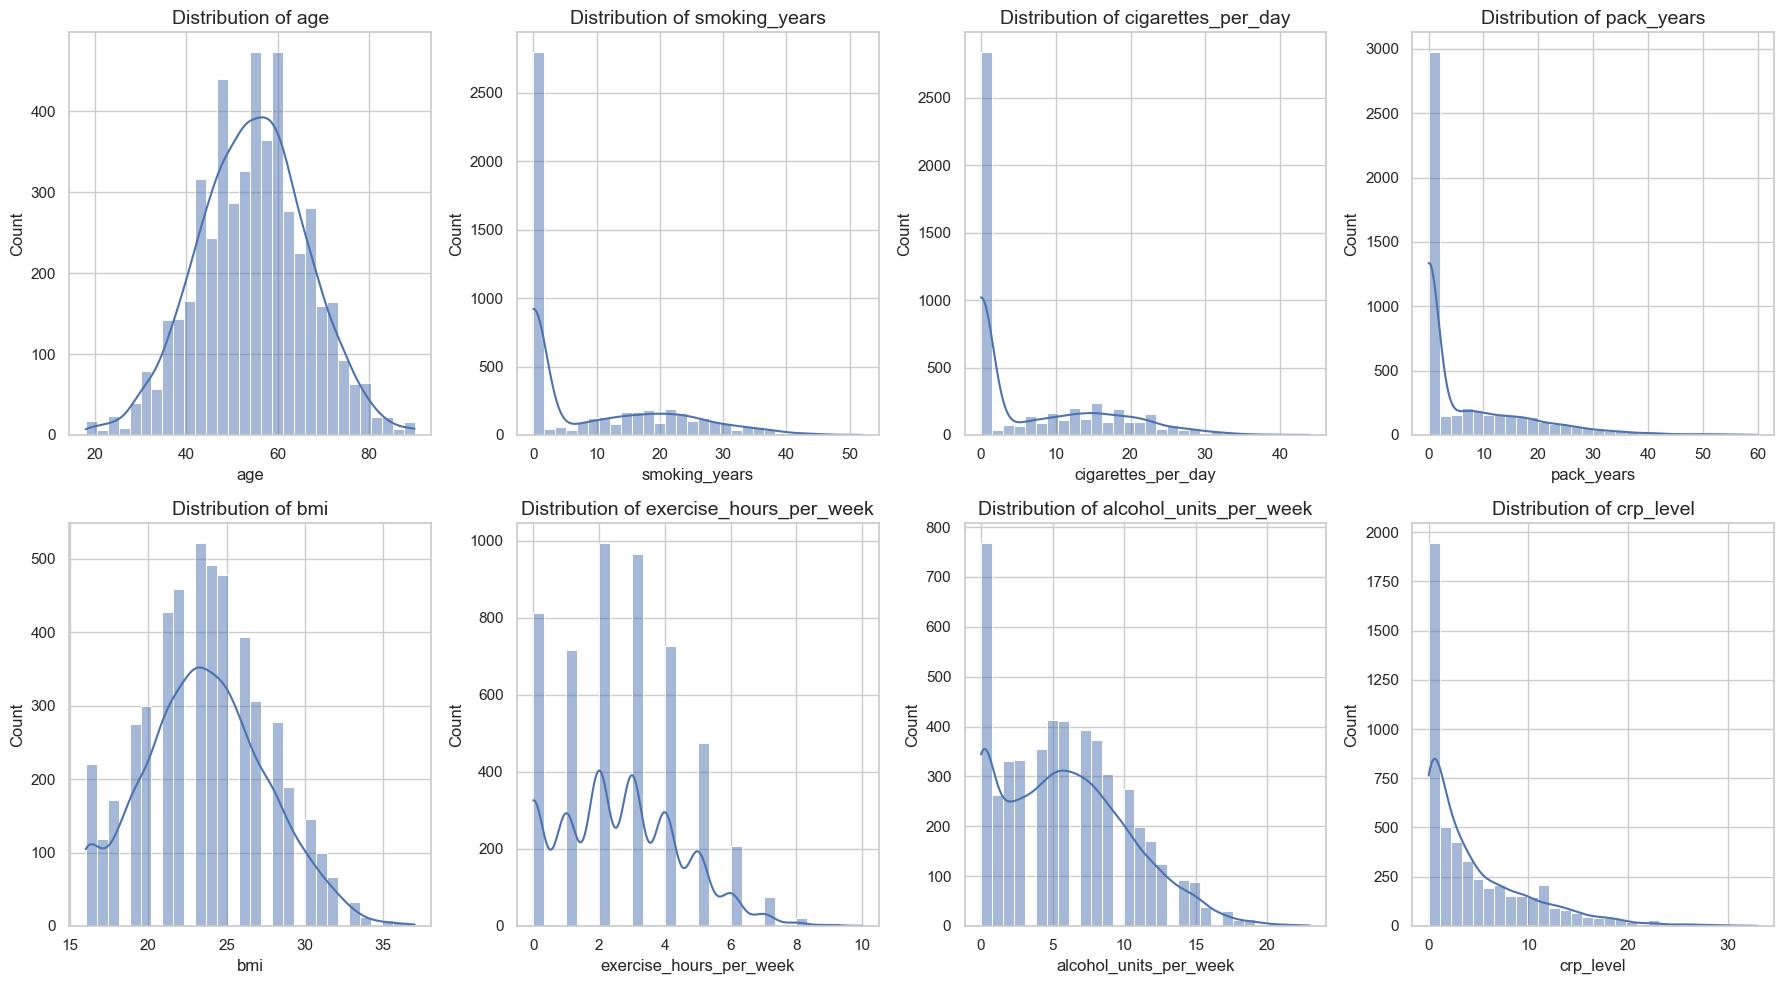

In [9]:
cols = 4
rows = math.ceil(len(numerical_vars)/cols)
fig, axes = plt.subplots(rows, cols, figsize=(18, 5*rows))

for i, var in enumerate(numerical_vars):
    r, c = divmod(i, cols)
    sns.histplot(df[var], kde=True, bins=30, ax=axes[r, c])
    axes[r, c].set_title(f'Distribution of {var}', fontsize=14)
    
# Remove empty subplots
for j in range(i+1, rows*cols):
    fig.delaxes(axes.flatten()[j])

plt.tight_layout()
plt.show()

### Count Plots

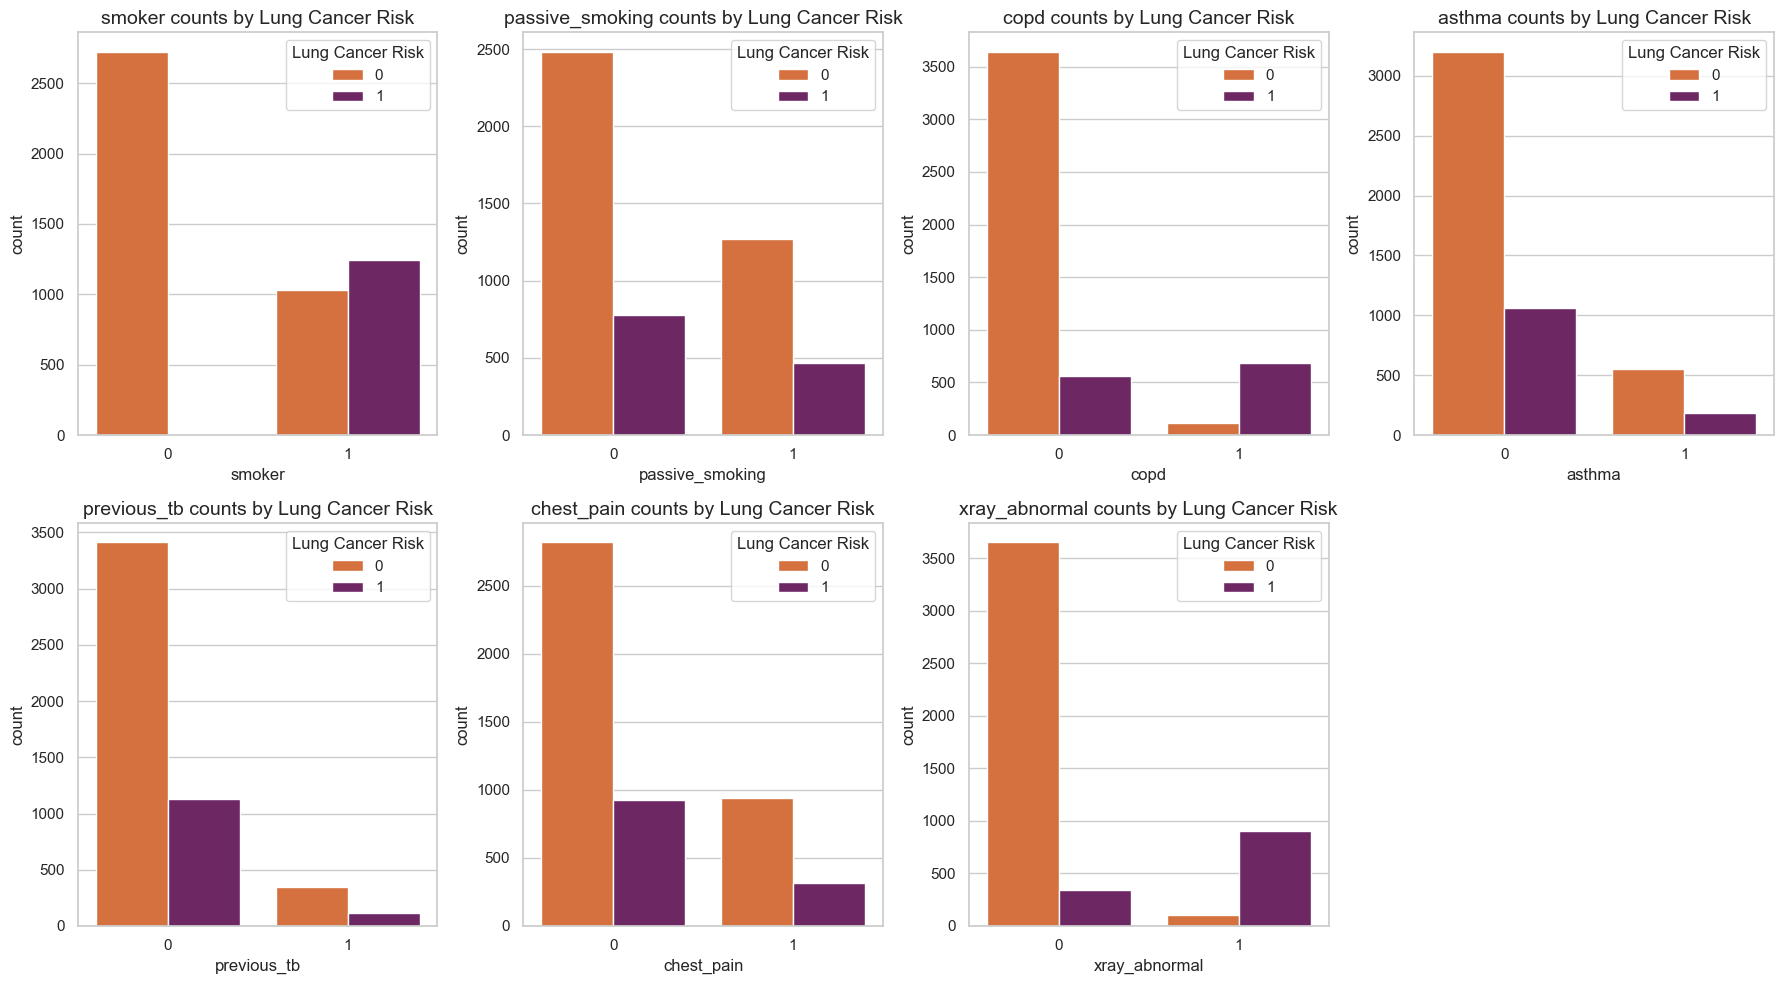

In [10]:
cols = 4
rows = math.ceil(len(categorical_vars)/cols)
fig, axes = plt.subplots(rows, cols, figsize=(18, 5*rows))

for i, var in enumerate(categorical_vars):
    r, c = divmod(i, cols)
    sns.countplot(x=var, data=df, hue='lung_cancer_risk', palette='inferno_r', ax=axes[r, c])
    axes[r, c].set_title(f'{var} counts by Lung Cancer Risk', fontsize=14)
    axes[r, c].legend(title='Lung Cancer Risk')

for j in range(i+1, rows*cols):
    fig.delaxes(axes.flatten()[j])

plt.tight_layout()
plt.show()

### Box plot

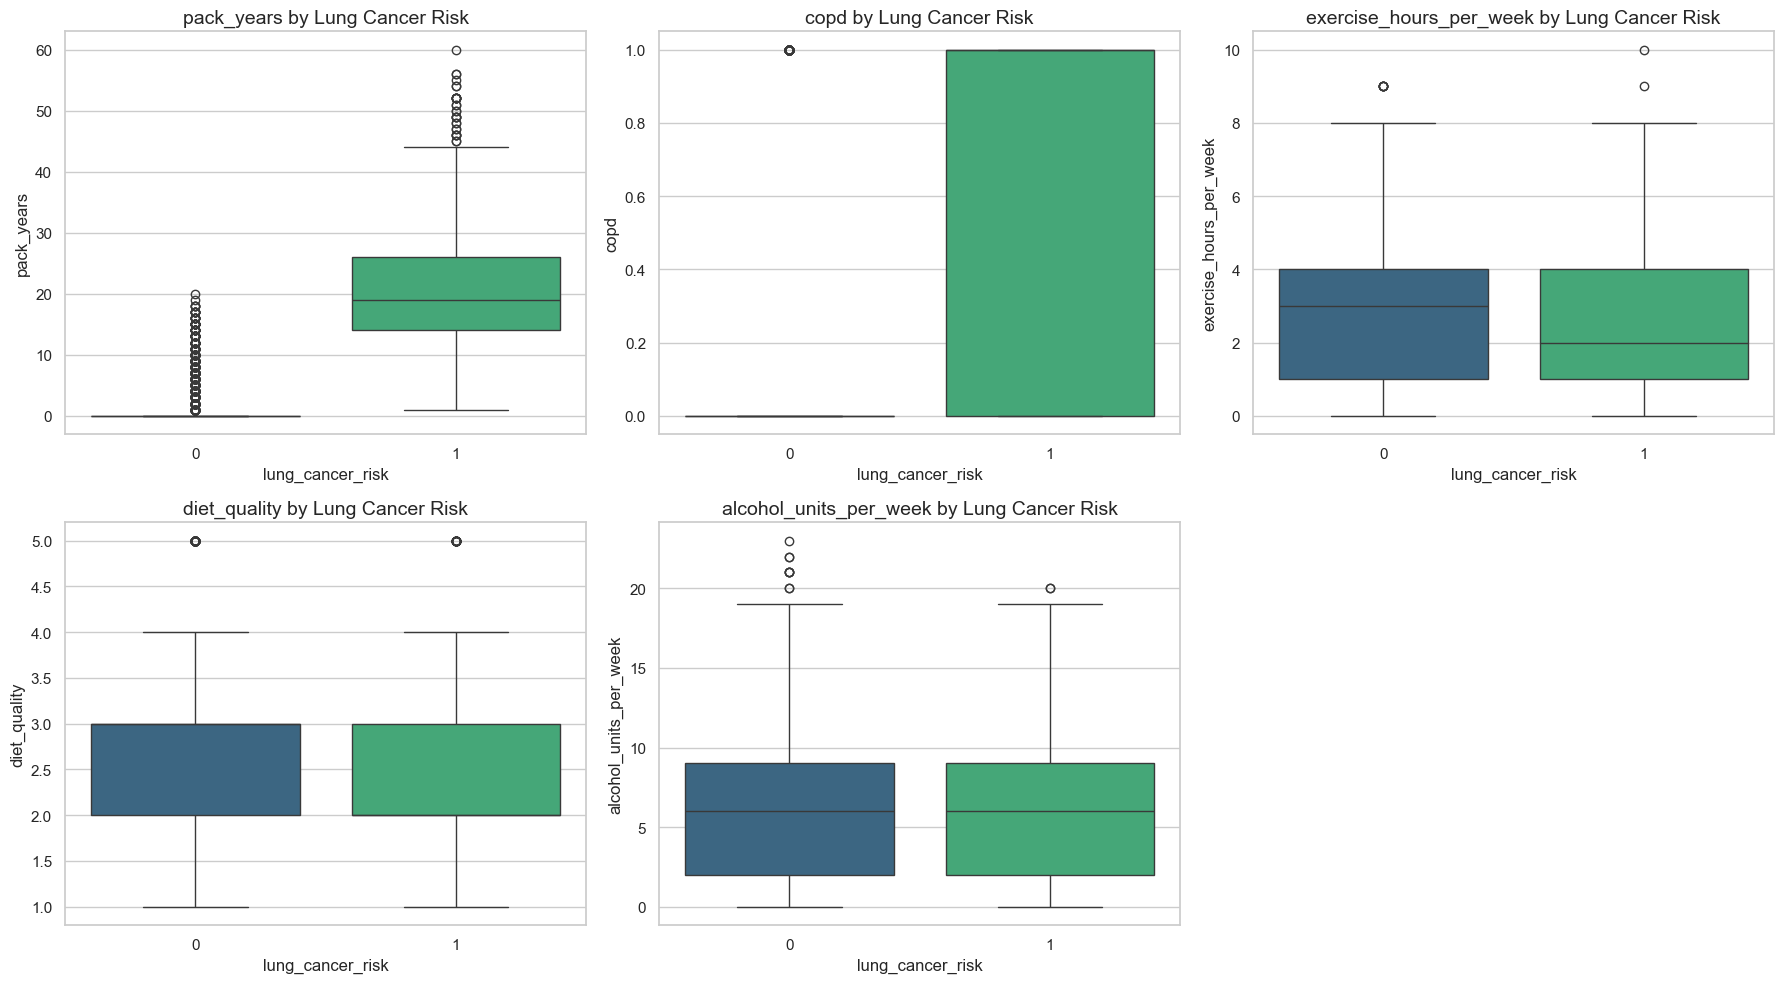

In [11]:
boxplot_vars = ['pack_years', 'copd', 'exercise_hours_per_week', 'diet_quality', 'alcohol_units_per_week']

cols = 3
rows = math.ceil(len(boxplot_vars)/cols)
fig, axes = plt.subplots(rows, cols, figsize=(18, 5*rows))

for i, var in enumerate(boxplot_vars):
    r, c = divmod(i, cols)
    sns.boxplot(x='lung_cancer_risk', y=var, data=df, palette='viridis', ax=axes[r, c])
    axes[r, c].set_title(f'{var} by Lung Cancer Risk', fontsize=14)

for j in range(i+1, rows*cols):
    fig.delaxes(axes.flatten()[j])

plt.tight_layout()
plt.show()

### Data Preparation
We will:
1. Mapping GENDER and LUNG_CANCER column to numerical features
2. Feature Selection
3. Data splitting (X,y, and train test split)
4. Standardization using StandardScaler (important for LogReg and GaussianNB)

In [12]:
# # confirm the data type is wrong
# print(f"Data type of GENDER column: {df["GENDER"].dtype}")
# print(f"Unique values of GENDER column: {df["GENDER"].unique()}\n")
# print(f"Data type of LUNG_CANCER column: {df['LUNG_CANCER'].dtype}")
# print(f"Unique values of LUNG_CANCER column: {df["LUNG_CANCER"].unique()}")

# # Encoding
# df_encoded = pd.get_dummies(df, columns= ["GENDER"])
# df_encoded["LUNG_CANCER"] = df["LUNG_CANCER"].map({"YES" : 1, "NO" : 0})
# df_encoded.rename(columns={"GENDER_M" : "MALE", "GENDER_F" : "FEMALE", "YELLOW_FINGERS" : "YELLOW FINGERS", "PEER_PRESSURE" : "PEER PRESSURE", "LUNG_CANCER" : "LUNG CANCER", "FATIGUE " : "FATIGUE", "ALLERGY " : "ALLERGY", "SWALLOWING_DIFFICULTY" : "SWALLOWING DIFFICULTY", "ALCOHOL_CONSUMING" : "ALCOHOL CONSUMING", "CHEST_PAIN" : "CHEST PAIN", "SHORTNESS_OF_BREATH" : "SHORTNESS OF BREATH", "CHRONIC_DISEASE" : "CHRONIC DISEASE"}, inplace=True)
# df_encoded = df_encoded[["AGE","MALE","FEMALE","ALCOHOL CONSUMING","CHEST PAIN","SHORTNESS OF BREATH","COUGHING","PEER PRESSURE","CHRONIC DISEASE","SWALLOWING DIFFICULTY","YELLOW FINGERS","ANXIETY","FATIGUE","ALLERGY","WHEEZING","LUNG CANCER"]]

# # Remove duplicate
# df_clean = df_encoded.drop_duplicates()

# # Check the dataset to confirm if the mapping is successful
# df_clean.info()

In [13]:
# df_clean.head()

<Axes: >

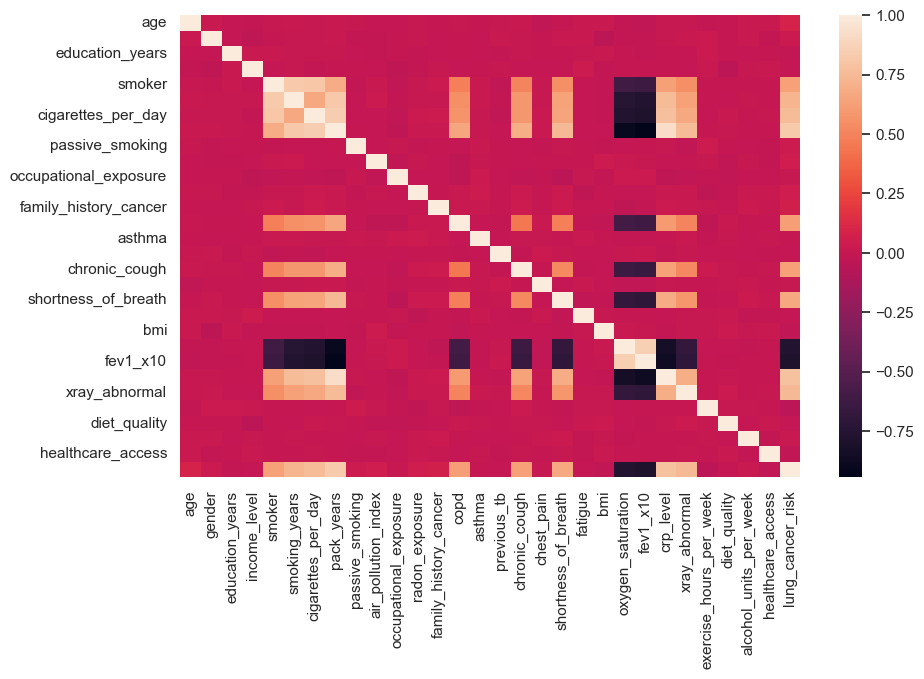

In [14]:
# Feature selection
df_corr = df.corr()
sns.heatmap(df_corr)

All feature have low correlation, so we can't use correlation matrix to do feature selection. Instead, we will use RandomForestClassifier faeture importance to do the feature selection. But before that, we need to split the Data to X and Y first.The correlation analysis shows that all features have low pairwise correlation, indicating weak linear relationships between variables and no significant redundancy. As a result, the correlation matrix is not suitable for feature selection in this case.

Since no features appear strongly correlated or redundant, all features are retained for model training to preserve as much information as possible. The dataset is then split into input features (X) and the target variable (y) before proceeding with modeling.

In [15]:
# Train test split
df.drop(['xray_abnormal', 'oxygen_saturation', 'fev1_x10', 'crp_level'], axis=1, inplace=True)
X = df.drop(columns=['lung_cancer_risk'])
y = df['lung_cancer_risk']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
# Scaler
ss = StandardScaler()

X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)

### Modeling
Configuration

In [17]:
# Configuration of CrossValidation and SMOTE oversampling
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
USE_SMOTE = True  # toggle this ON/OFF to compare impact

# Imbalance ratio for XGBClassifier
ratio = (y_train == 0).sum() / (y_train == 1).sum()

In [18]:
# Confusion Matrix helper
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [19]:
# Model Definition
models = {
    "LogReg": {
        "base": SkPipeline([
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
        ]),
        "tuned_pipeline": ImbPipeline([
            ('scaler', StandardScaler()),
            ('smote', SMOTE(random_state=42)) if USE_SMOTE else ('passthrough', 'passthrough'),
            ('model', LogisticRegression(max_iter=1000))
        ]),
        "param_grid": {
            'model__C': [0.01, 0.1, 1, 10],
            'model__penalty': ['l2'],
            'model__class_weight': [None, 'balanced']
        }
    },

    "GaussianNB": {
        "base": SkPipeline([
            ('scaler', StandardScaler()),
            ('model', GaussianNB())
        ]),
        "tuned_pipeline": ImbPipeline([
            ('scaler', StandardScaler()),
            ('smote', SMOTE(random_state=42)) if USE_SMOTE else ('passthrough', 'passthrough'),
            ('model', GaussianNB())
        ]),
        "param_grid": {
            'model__var_smoothing': [1e-9, 1e-8, 1e-7]
        }
    },

    "XGBoost": {
        "base": SkPipeline([
            ('scaler', StandardScaler()),
            ('model', XGBClassifier(
                eval_metric='logloss',
                use_label_encoder=False,
                scale_pos_weight=ratio
            ))
        ]),
        "tuned_pipeline": ImbPipeline([
            ('scaler', StandardScaler()),
            ('smote', SMOTE(random_state=42)) if USE_SMOTE else ('passthrough', 'passthrough'),
            ('model', XGBClassifier(
                eval_metric='logloss',
                use_label_encoder=False
            ))
        ]),
        "param_grid": {
            'model__n_estimators': [50, 100],
            'model__max_depth': [3, 5],
            'model__learning_rate': [0.01, 0.1],
            'model__scale_pos_weight': [1, ratio]
        }
    }
}


==================== LogReg ====================

--- BASE ---
              precision    recall  f1-score   support

           0       0.99      0.96      0.98       746
           1       0.90      0.97      0.94       254

    accuracy                           0.97      1000
   macro avg       0.95      0.97      0.96      1000
weighted avg       0.97      0.97      0.97      1000



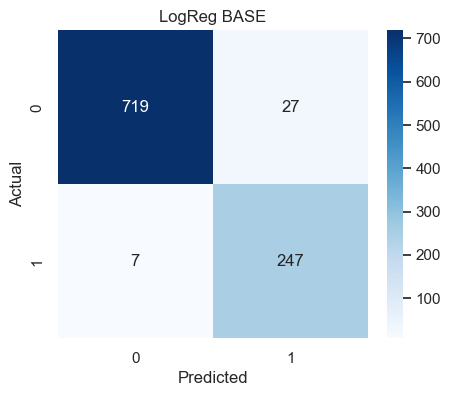


--- TUNED ---
Best Params: {'model__C': 10, 'model__class_weight': None, 'model__penalty': 'l2'}
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       746
           1       0.91      0.96      0.94       254

    accuracy                           0.97      1000
   macro avg       0.95      0.96      0.96      1000
weighted avg       0.97      0.97      0.97      1000



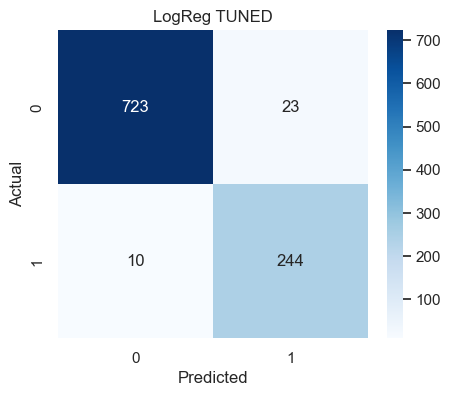


==================== GaussianNB ====================

--- BASE ---
              precision    recall  f1-score   support

           0       1.00      0.78      0.87       746
           1       0.60      1.00      0.75       254

    accuracy                           0.83      1000
   macro avg       0.80      0.89      0.81      1000
weighted avg       0.90      0.83      0.84      1000



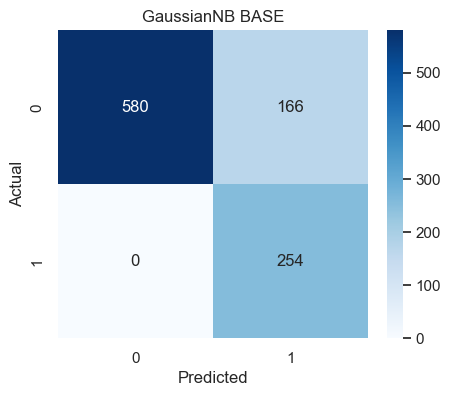


--- TUNED ---
Best Params: {'model__var_smoothing': 1e-07}
              precision    recall  f1-score   support

           0       1.00      0.82      0.90       746
           1       0.65      1.00      0.79       254

    accuracy                           0.86      1000
   macro avg       0.82      0.91      0.84      1000
weighted avg       0.91      0.86      0.87      1000



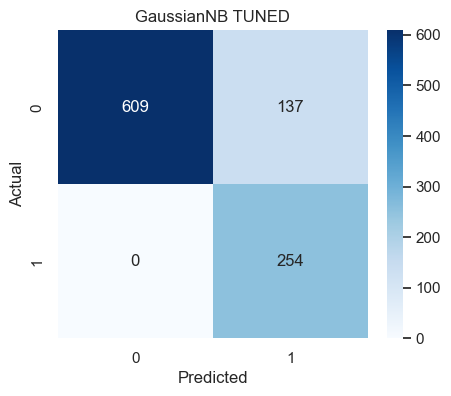


==================== XGBoost ====================

--- BASE ---
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       746
           1       0.93      0.94      0.94       254

    accuracy                           0.97      1000
   macro avg       0.96      0.96      0.96      1000
weighted avg       0.97      0.97      0.97      1000



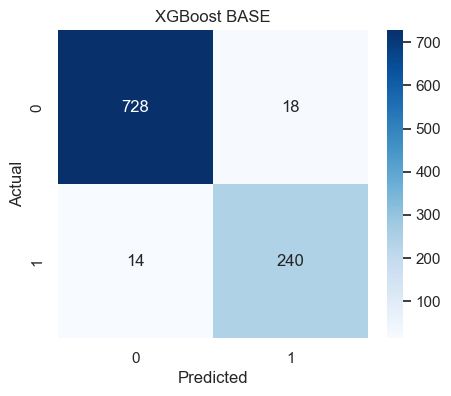


--- TUNED ---
Best Params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__scale_pos_weight': 1}
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       746
           1       0.92      0.96      0.94       254

    accuracy                           0.97      1000
   macro avg       0.95      0.96      0.96      1000
weighted avg       0.97      0.97      0.97      1000



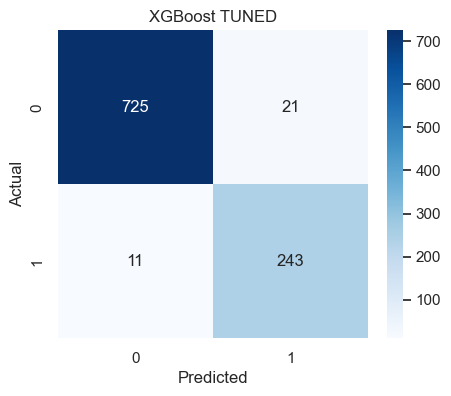

In [20]:
results = []

for name, config in models.items():
    print(f"\n==================== {name} ====================")

    # ===== BASE MODEL =====
    base_model = config["base"]
    base_model.fit(X_train, y_train)
    y_pred_base = base_model.predict(X_test)

    f1_base = f1_score(y_test, y_pred_base, average='macro')

    print("\n--- BASE ---")
    print(classification_report(y_test, y_pred_base))
    plot_cm(y_test, y_pred_base, f"{name} BASE")

    results.append({
        "Model": name,
        "Type": "Base",
        "F1_macro": f1_base
    })

    # ===== TUNED MODEL =====
    grid = GridSearchCV(
        config["tuned_pipeline"],
        config["param_grid"],
        cv=skf,
        scoring='f1_macro',
        n_jobs=-1
    )

    grid.fit(X_train, y_train)
    y_pred_tuned = grid.predict(X_test)

    f1_tuned = f1_score(y_test, y_pred_tuned, average='macro')

    print("\n--- TUNED ---")
    print("Best Params:", grid.best_params_)
    print(classification_report(y_test, y_pred_tuned))
    plot_cm(y_test, y_pred_tuned, f"{name} TUNED")

    results.append({
        "Model": name,
        "Type": "Tuned",
        "F1_macro": f1_tuned
    })

In [21]:
df_results = pd.DataFrame(results)
print("\n=== FINAL COMPARISON ===")
print(df_results.sort_values(by="F1_macro", ascending=False))


=== FINAL COMPARISON ===
        Model   Type  F1_macro
5     XGBoost  Tuned  0.958316
4     XGBoost   Base  0.957997
1      LogReg  Tuned  0.957174
0      LogReg   Base  0.956254
3  GaussianNB  Tuned  0.843245
2  GaussianNB   Base  0.814260
